C:\Users\S.P.M. de Vette\AppData\Local\Temp\ipykernel_24172\1202492043.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\S.P.M. de Vette\AppData\Local\Temp\ipykernel_24172\1202492043.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


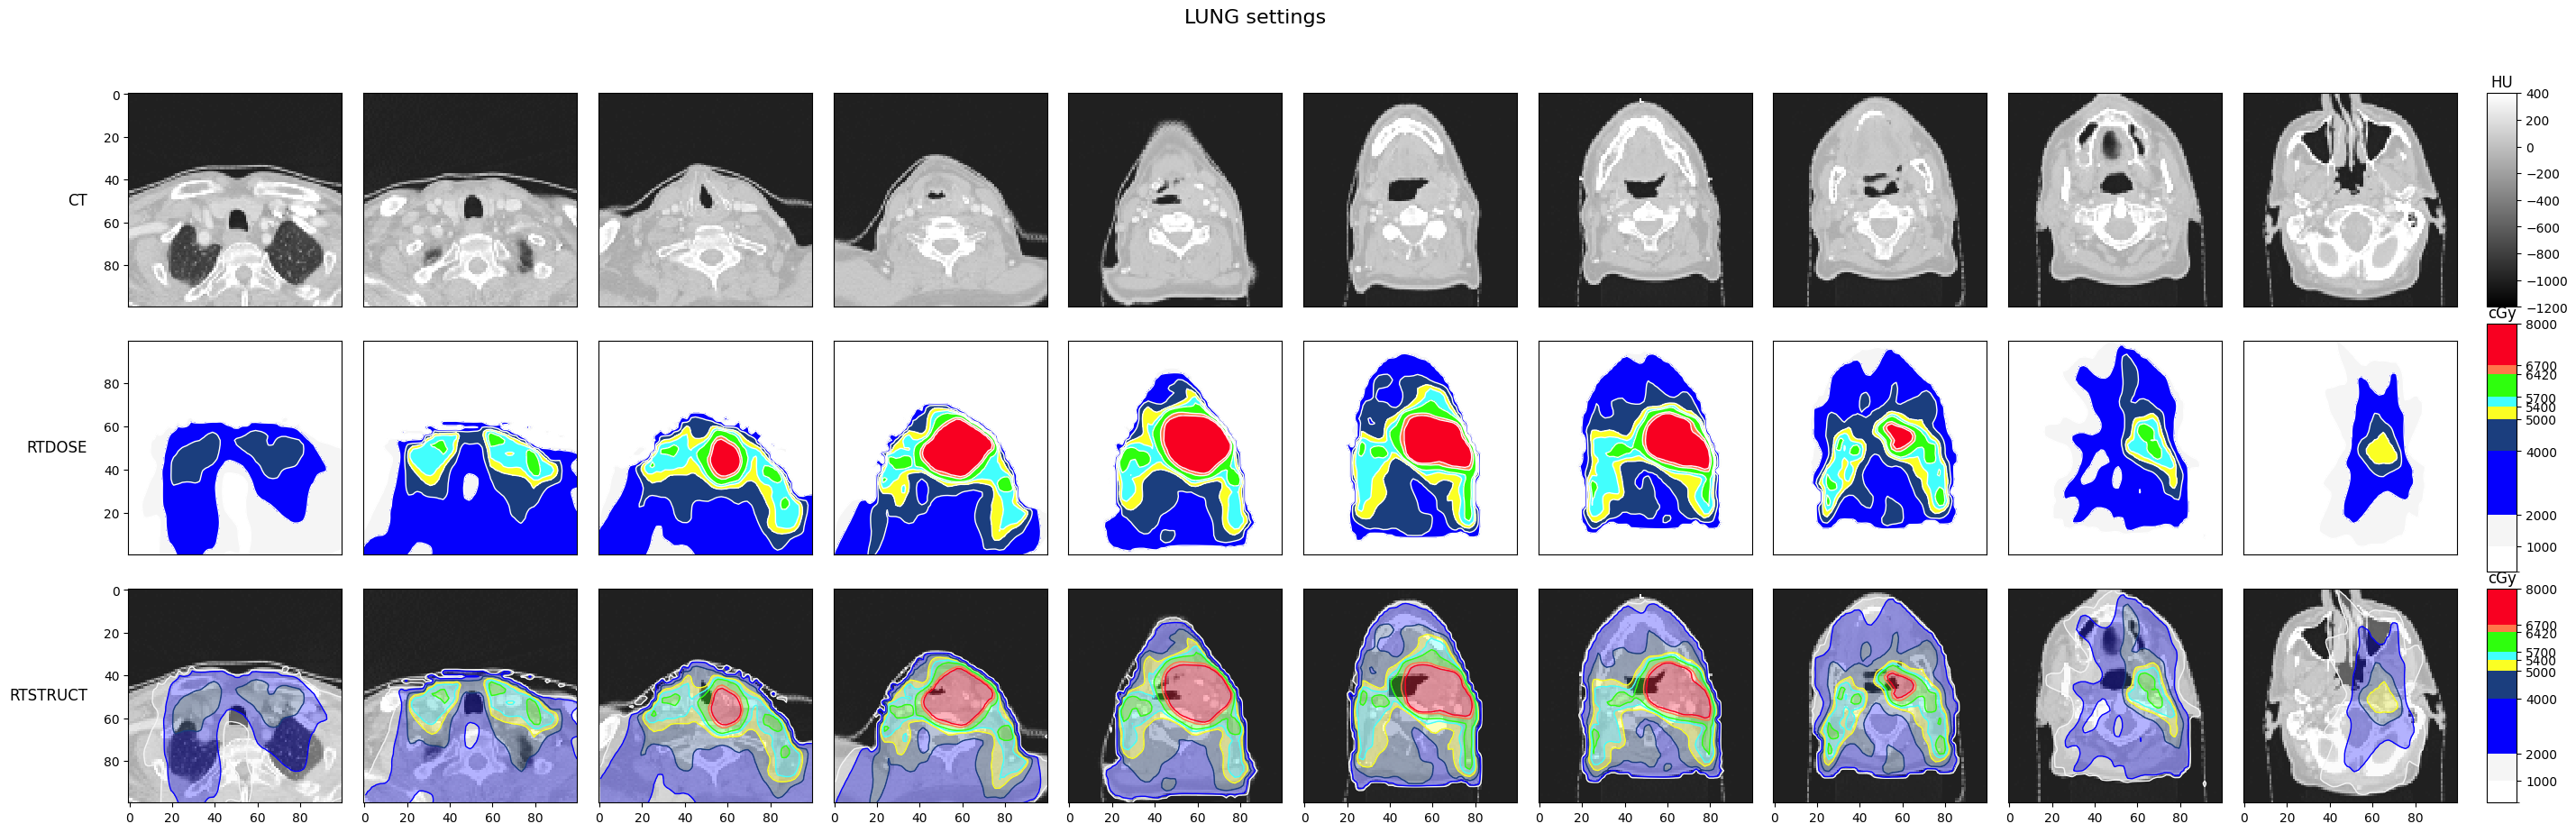

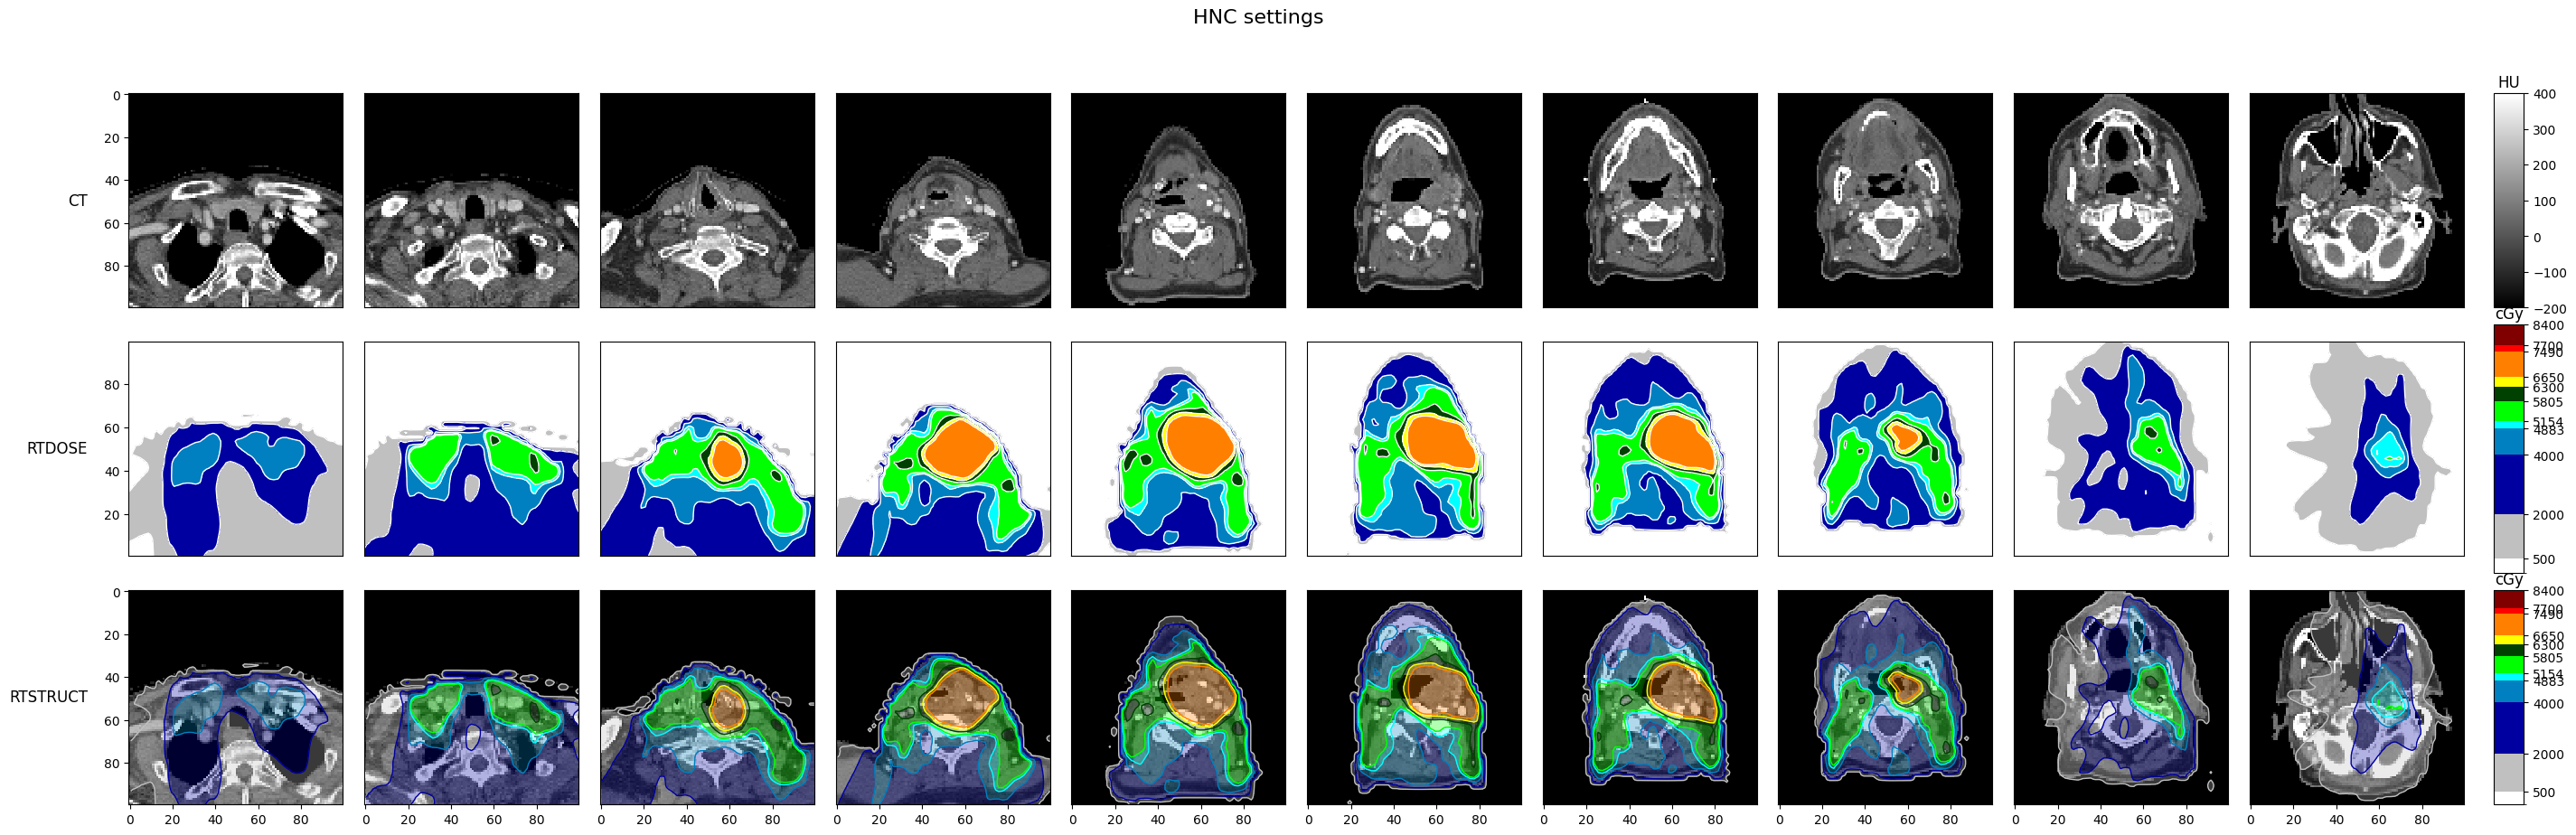

In [ ]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from src.visualization.plot_slices import plot_slices



patient_folder = r"C:\Users\S.P.M. de Vette\OneDrive - UMCG\Documents\DL_NTCP_Multitox\datasets\MT_dataset\patients\0070426"
CT = np.load(os.path.join(patient_folder, "ct.npy"))[0]
RTDOSE = np.load(os.path.join(patient_folder, "rtdose.npy"))[0]
RTSTRUCT = np.load(os.path.join(patient_folder, "segmentation_map.npy"))[0]

plotting_rows_dicts = [
    {
        "Label": "CT",
        "CT": CT
    },
    {
        "Label": "RTDOSE",
        "RTDOSE": RTDOSE
    },
    {
        "Label": "RTSTRUCT",
        "CT": CT,
        "RTDOSE": RTDOSE,
        #"RTSTRUCT": RTSTRUCT
    }
]

num_CT_slices = CT.shape[0]
num_plot_slices = 10

slices = list(range(0, num_CT_slices, num_CT_slices // (num_plot_slices + 1)))[1:-1]


#slices = [20, 30, 40, 50, 60, 70, 80, 90]
fig, axes = plot_slices(plotting_rows_dicts, slices, RT_region="LUNG", title="LUNG settings")# , title=f"{patient_id} slices")\

fig.show()

#slices = [20, 30, 40, 50, 60, 70, 80, 90]
fig, axes = plot_slices(plotting_rows_dicts, slices, RT_region="HNC", title="HNC settings")# , title=f"{patient_id} slices")\

fig.show()


torch.Size([8, 2, 96, 96, 96])
torch.Size([8, 1, 96, 96, 96])


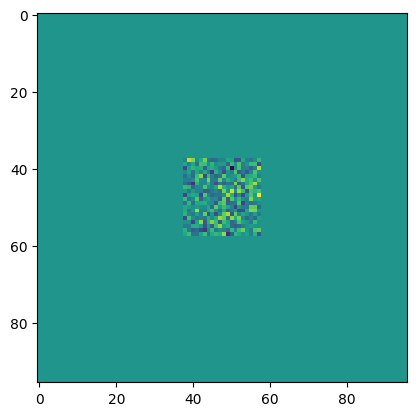

In [6]:
import torch
import matplotlib.pyplot as plt

# Create a tensor of noise with the shape [8, 2, 96, 96, 96]
noise_tensor = torch.randn(8, 2, 96, 96, 96)
print(noise_tensor.shape)

binary_tensor = torch.zeros(8, 1, 96, 96, 96)
binary_tensor[:, :, 38:58, 38:58, 38:58] = 1
print(binary_tensor.shape)

x = noise_tensor * binary_tensor

plt.imshow(x[0, 0, 50, :, :])


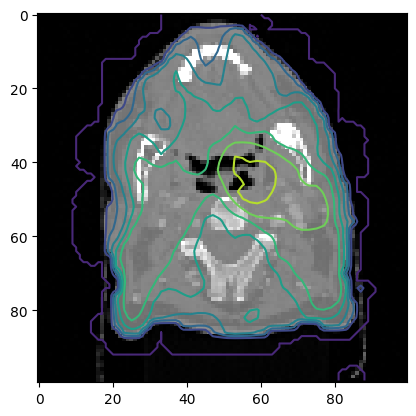

In [4]:
plt.imshow(CT[70], cmap='gray', interpolation='none')
plt.contour(RTDOSE[70])

C:\Users\S.P.M. de Vette\AppData\Local\Temp\ipykernel_24172\2125199391.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', 17)


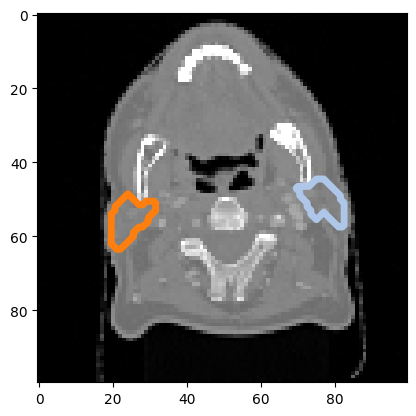

In [5]:
# Define a colormap with 16 different colors
cmap = plt.cm.get_cmap('tab20', 17)

# Create a dictionary to map values to colors
value_color_mapping = {i: cmap(i) for i in range(1, 16)}

mask = np.isin(RTSTRUCT, [1, 2, 3, 4])

RTSTRUCT_MASKED = np.where(mask, RTSTRUCT, 0)


# Plot the CT slice with the RTSTRUCT contours in different colors
plt.imshow(CT[70], cmap='gray', interpolation='none')
for value, color in value_color_mapping.items():
    plt.contour(RTSTRUCT_MASKED[70] == value, colors=[color], linewidths=5) #, levels=[0.5])

plt.show()

In [6]:
seg16 = RTSTRUCT[70] == value

np.unique(seg16)

array([False,  True])